# STEP 1: IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

# STEP 2: LOAD DATA

In [3]:
df = pd.read_csv("/content/fullcleaned_house_data.csv")

# STEP 3: REMOVE DATA LEAKAGE

In [4]:
df = df.drop(columns=["area_rate"], errors="ignore")

# STEP 4: FEATURE ENGINEERING

In [5]:
df["total_rooms"] = df["beds"] + df["bathrooms"]
df["area_log"] = np.log1p(df["area"])

# STEP 5: TARGET ENCODING

In [6]:
locality_mean = df.groupby("locality")["rent"].mean()
df["locality_encoded"] = df["locality"].map(locality_mean)

city_mean = df.groupby("city")["rent"].mean()
df["city_encoded"] = df["city"].map(city_mean)

df = df.drop(["locality", "city", "area"], axis=1)

# STEP 6: FEATURE & TARGET

In [7]:
X = df.drop("rent", axis=1)
y = np.log1p(df["rent"])

# STEP 7: ENCODING

In [9]:
import os
import pickle

# Create model folder inside /content
os.makedirs("/content/model", exist_ok=True)

# Save encoders
with open("/content/model/encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("Encoders saved successfully!")

Encoders saved successfully!


In [11]:
from sklearn.preprocessing import LabelEncoder
import pickle
import os

categorical_cols = ["furnishing", "house_type"]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    X[col] = le.fit_transform(X[col])

    encoders[col] = le

# Create model folder
os.makedirs("/content/model", exist_ok=True)

# Save encoders
with open("/content/model/encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("Encoders saved successfully!")

Encoders saved successfully!


In [12]:
print(X[["furnishing", "house_type"]].head())

   furnishing  house_type
0           1        2400
1           1         694
2           2        1193
3           2        1916
4           2         819


In [13]:
print(encoders)

{'furnishing': LabelEncoder(), 'house_type': LabelEncoder()}


In [14]:
for col, le in encoders.items():
    print(col)
    print(le.classes_)

furnishing
[0 1 2]
house_type
[   0    1    2 ... 5404 5405 5406]


In [15]:
with open("/content/model/encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

# STEP 8: TRAIN TEST SPLIT

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# STEP 9: MODELS

In [17]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(max_depth=10),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}


# STEP 10: TRAIN + EVALUATE

In [18]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred_log = model.predict(X_test)

    # reverse log
    y_pred = np.expm1(y_pred_log)
    y_actual = np.expm1(y_test)

    mae = mean_absolute_error(y_actual, y_pred)
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_actual, y_pred)

    results.append([name, mae, mse, rmse, r2])

    print(f"\n{name}")
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)


Linear Regression
MAE: 19287.553447701703
MSE: 4078106405.162082
RMSE: 63860.05328186066
R2: 0.45583218369852896

Decision Tree
MAE: 16358.045896726646
MSE: 1708143801.4769132
RMSE: 41329.696363231524
R2: 0.7720714493368787

Random Forest
MAE: 13520.725528265646
MSE: 1034120753.0529507
RMSE: 32157.747947469063
R2: 0.8620106549283402

XGBoost
MAE: 13753.90339885511
MSE: 1211734835.5085597
RMSE: 34809.98183723398
R2: 0.8383104721003698


# STEP 11: RESULTS TABLE

In [19]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R2"])
results_df = results_df.sort_values(by="R2", ascending=False)

print("\nFinal Comparison:\n")
print(results_df)


Final Comparison:

               Model           MAE           MSE          RMSE        R2
2      Random Forest  13520.725528  1.034121e+09  32157.747947  0.862011
3            XGBoost  13753.903399  1.211735e+09  34809.981837  0.838310
1      Decision Tree  16358.045897  1.708144e+09  41329.696363  0.772071
0  Linear Regression  19287.553448  4.078106e+09  63860.053282  0.455832


# STEP 12: VISUALIZATION (MODEL COMPARISON)

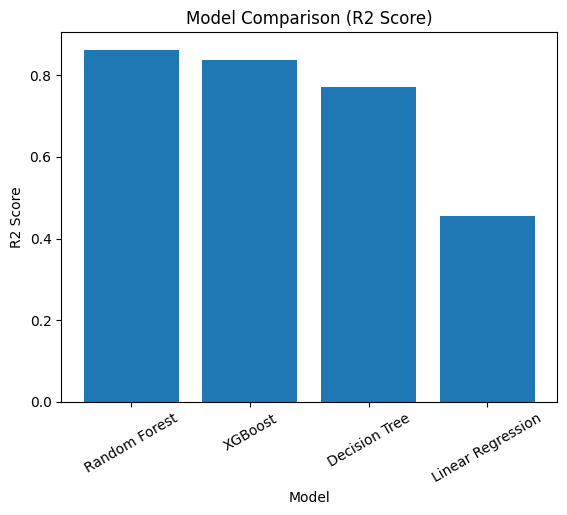

In [20]:
plt.figure()
plt.bar(results_df["Model"], results_df["R2"])
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)
plt.show()

# STEP 13: BEST MODEL

In [21]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)

print("\nBest Model:", best_model_name)


Best Model: Random Forest


# STEP 14: CROSS VALIDATION

In [22]:
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="r2")
print("\nCross Validation R2:", cv_scores.mean())


Cross Validation R2: 0.8790296451091557


# STEP 15: PREDICTION GRAPH (ACTUAL vs PREDICTED)

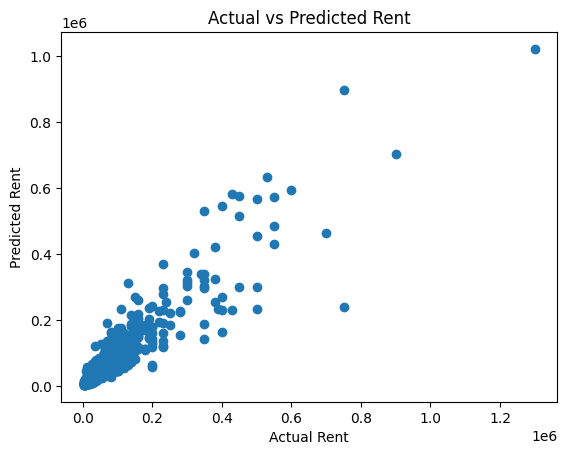

In [23]:
y_pred_log = best_model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

plt.figure()
plt.scatter(y_actual, y_pred)
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs Predicted Rent")
plt.show()

# STEP 16: SAVE MODEL

In [25]:
import os
import pickle

# Create model folder if it does not exist
os.makedirs("/content/model", exist_ok=True)

# Save trained model
with open("/content/model/house_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save locality mean encoding
with open("/content/model/locality_mean.pkl", "wb") as f:
    pickle.dump(locality_mean, f)

# Save city mean encoding
with open("/content/model/city_mean.pkl", "wb") as f:
    pickle.dump(city_mean, f)

print("Model Saved Successfully")

Model Saved Successfully
